Loading CSV...
Total rows: 8064000
Unique edges: 12000
Using edge: 5628016048_5606845181_0
Time series length: 672
Train length: 470
Test length : 202
Fitting ARIMA(2, 1, 2) on training data...
                                SARIMAX Results                                
Dep. Variable:     travel_time_seconds   No. Observations:                  470
Model:                  ARIMA(2, 1, 2)   Log Likelihood               -1650.444
Date:                 Tue, 10 Mar 2026   AIC                           3310.888
Time:                         09:47:31   BIC                           3331.641
Sample:                     02-15-2025   HQIC                          3319.054
                          - 02-19-2025                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1   

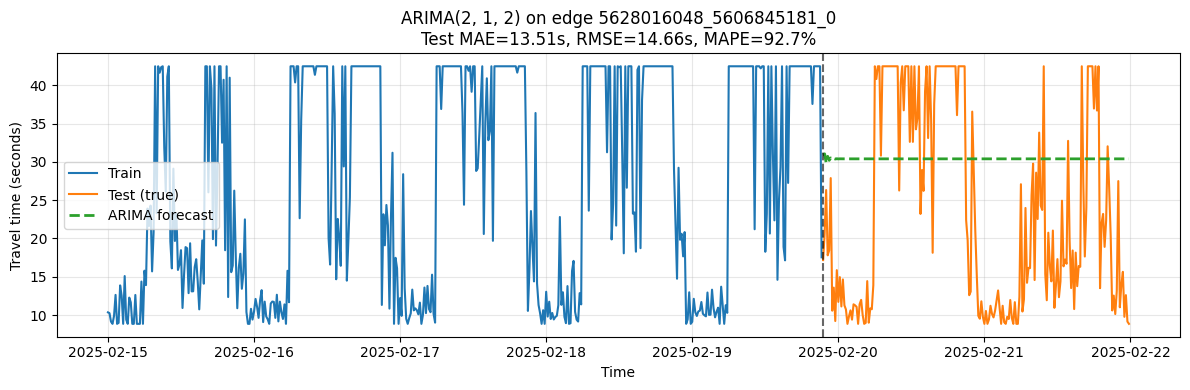

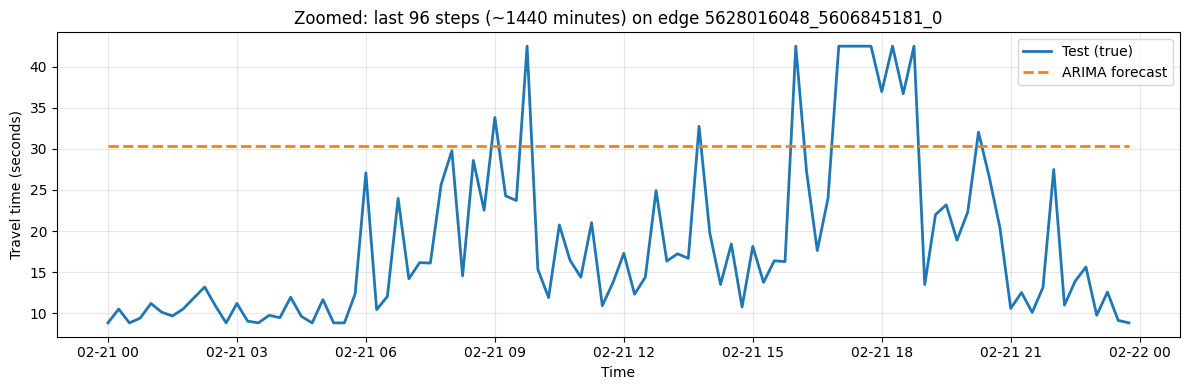

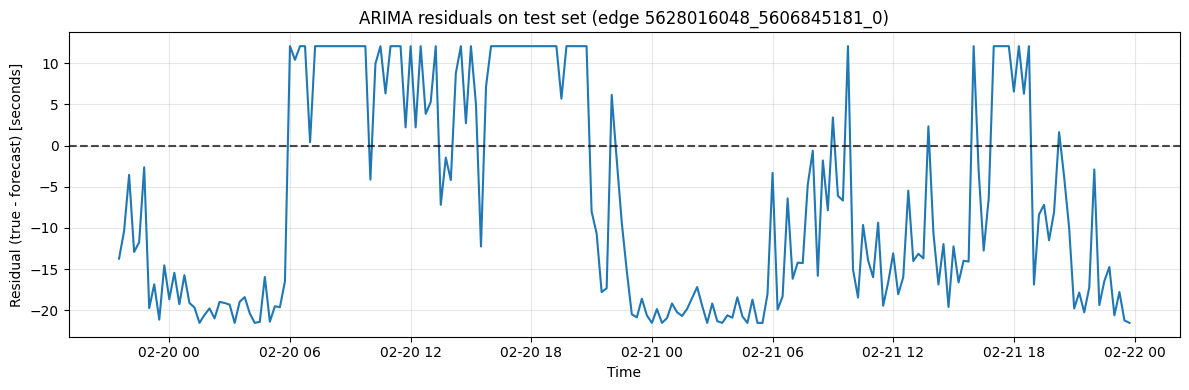

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# -------------------------
# CONFIG
# -------------------------
PATH = "/content/drive/MyDrive/traffic_data/dhaka_timeseries_2025-02-15_7d_15min.csv"
FREQ = "15min"       # simulator freq
TARGET_COL = "travel_time_seconds"
TRAIN_FRACTION = 0.7   # 70% train, 30% test
ARIMA_ORDER = (2, 1, 2)   # (p,d,q) – can tune later

# -------------------------
# 1) Load data
# -------------------------
print("Loading CSV...")
df = pd.read_csv(
    PATH,
    parse_dates=["timestamp"]
)

# create an edge_id to work with a single univariate series
df["edge_id"] = (
    df["u"].astype(str)
    + "_"
    + df["v"].astype(str)
    + "_"
    + df["key"].astype(str)
)

print("Total rows:", len(df))
print("Unique edges:", df["edge_id"].nunique())

# pick edge with most data (you can also hardcode a specific edge_id if you want)
top_edge_id = df["edge_id"].value_counts().idxmax()
print("Using edge:", top_edge_id)

edge_df = df[df["edge_id"] == top_edge_id].copy()
edge_df = edge_df.sort_values("timestamp")

# -------------------------
# 2) Build regular 15-min time series & handle missing timestamps
# -------------------------
time_index = pd.date_range(
    start=edge_df["timestamp"].min(),
    end=edge_df["timestamp"].max(),
    freq=FREQ
)

ts = (
    edge_df.set_index("timestamp")[TARGET_COL]
           .reindex(time_index)
           .interpolate(method="time")   # fill small gaps smoothly
           .ffill()
           .bfill()
)

ts.name = TARGET_COL
print("Time series length:", len(ts))

# -------------------------
# 3) Train/Test split
# -------------------------
n = len(ts)
n_train = int(TRAIN_FRACTION * n)

train = ts.iloc[:n_train]
test  = ts.iloc[n_train:]

print("Train length:", len(train))
print("Test length :", len(test))

# -------------------------
# 4) Fit ARIMA on training data
# -------------------------
print(f"Fitting ARIMA{ARIMA_ORDER} on training data...")
model = ARIMA(train, order=ARIMA_ORDER)
model_fit = model.fit()
print(model_fit.summary())

# -------------------------
# 5) Forecast on test horizon
# -------------------------
print("Forecasting on test set horizon...")
# forecast 'len(test)' steps ahead from end of training
forecast = model_fit.forecast(steps=len(test))

# align index with test
forecast.index = test.index

# -------------------------
# 6) Metrics (MAE, RMSE, MAPE) on test
# -------------------------
def compute_metrics(y_true, y_pred, prefix="ARIMA | "):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    eps = 1e-3
    mape = np.mean(
        np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))
    ) * 100.0

    print(f"{prefix}MAE : {mae:.4f} s")
    print(f"{prefix}RMSE: {rmse:.4f} s")
    print(f"{prefix}MAPE: {mape:.2f}%")

    return mae, rmse, mape

arima_mae, arima_rmse, arima_mape = compute_metrics(test, forecast)

# -------------------------
# 7) PLOTS
#   Plot 1: Full series with train/test/forecast
#   Plot 2: Zoomed-in test region
#   Plot 3: Residuals vs time
# -------------------------

# ---- Plot 1: full series ----
plt.figure(figsize=(12,4))
plt.plot(train.index, train.values, label="Train", linewidth=1.5)
plt.plot(test.index,  test.values,  label="Test (true)", linewidth=1.5)
plt.plot(forecast.index, forecast.values, "--", label="ARIMA forecast", linewidth=2)
plt.axvline(test.index[0], color="k", linestyle="--", alpha=0.6)
plt.title(
    f"ARIMA{ARIMA_ORDER} on edge {top_edge_id}\n"
    f"Test MAE={arima_mae:.2f}s, RMSE={arima_rmse:.2f}s, MAPE={arima_mape:.1f}%"
)
plt.xlabel("Time")
plt.ylabel("Travel time (seconds)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Plot 2: zoomed test region (e.g., last 1 day of test) ----
steps_per_day = int(pd.Timedelta("1D") / pd.Timedelta(FREQ))
zoom_steps = min(steps_per_day, len(test))  # at most 1 day, or less if test smaller
test_zoom = test.iloc[-zoom_steps:]
forecast_zoom = forecast.iloc[-zoom_steps:]

plt.figure(figsize=(12,4))
plt.plot(test_zoom.index, test_zoom.values, label="Test (true)", linewidth=2)
plt.plot(forecast_zoom.index, forecast_zoom.values, "--", label="ARIMA forecast", linewidth=2)
plt.title(f"Zoomed: last {zoom_steps} steps (~{zoom_steps * 15} minutes) on edge {top_edge_id}")
plt.xlabel("Time")
plt.ylabel("Travel time (seconds)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Plot 3: residuals vs time ----
residuals = test - forecast

plt.figure(figsize=(12,4))
plt.plot(residuals.index, residuals.values, linewidth=1.5)
plt.axhline(0.0, color="k", linestyle="--", alpha=0.7)
plt.title(f"ARIMA residuals on test set (edge {top_edge_id})")
plt.xlabel("Time")
plt.ylabel("Residual (true - forecast) [seconds]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
